In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tanalysis import improcess, stitching
import pandas as pd
from skimage import exposure


dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Originals\24h_CXCL10_Conc10_z5_t8h.lif"

In [2]:
imgs, dim, names, info = improcess.imread(dirname, channel=0, tiles=True)

Reading submitted files: 100%|████████████████████████████████████████| 1/1 [00:38<00:00, 38.60s/it]


All files read!


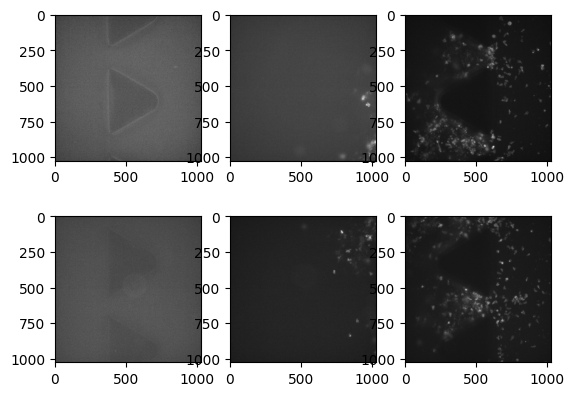

In [3]:
timestamp = imgs[0][0]
positions = info['mosaic_position']
grid = {}
nrow = 0
ncol = 0

for pos, tile in zip(positions, timestamp):
    #Recorder of number of rows and cols
    if pos[1]+1>nrow:
        nrow=pos[1]+1
    if pos[0]+1>ncol:
        ncol=pos[0]+1
    #Assigning to the dictionary the corresponding image to each combination of row, col
    eq_tile = exposure.equalize_hist(tile,)
    grid[f'{pos[1]}{pos[0]}'] = tile

fig, ax = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax[row, col].imshow(grid[f'{row}{col}'][5], cmap='gray')

In [21]:
translations = {} #Saving vertical an horizontal translations for each image
z = 7
for row in range(0, nrow):
    for col in range(0, ncol):
        im = grid[f'{row}{col}'][z]
        if row==0:
            Tvrow = 0
            Tvcol = 0
        if col==0:
            Throw = 0
            Thcol = 0
        if row!=0:
            im2 = grid[f'{row-1}{col}'][z]
            _, Tvrow, Tvcol = stitching.pciam(im2, im, n=10)
        if col!=0:
            im2 = grid[f'{row}{col-1}'][z]
            _, Throw, Thcol = stitching.pciam(im2, im, n=10)
        translations[f'{row}{col}'] = [[int(Tvrow), int(Tvcol)], [int(Throw), int(Thcol)]]
print(translations)

{'00': [[0, 0], [0, 0]], '01': [[0, 0], [-8, -151]], '02': [[0, 0], [475, 1015]], '10': [[-281, 11], [0, 0]], '11': [[974, -176], [971, -772]], '12': [[-317, 63], [-993, 327]]}


In [28]:
# Transform local translations to global translations with reference on image 0
rows = []
cols = []
prer = 0
for row in np.arange(nrow):
    prec = 0
    for col in np.arange(ncol):
        Tv, Th = translations[f'{row}{col}']
        if row==0 or col==0:
            rowind = Tv[0]+Th[0]
            colind = Tv[1]+Th[1]
        else:
            rowind = min(Tv[0], Th[0])
            colind = min(Tv[1], Th[1])
        cols.append(colind + prec)
        rows.append(rowind + prer)
        prec = colind
    prer = rowind
print(rows, cols)

[0, -8, 475, 194, 1446, -518] [0, -151, 864, 11, -761, -709]


In [17]:
translations = {} #Saving vertical an horizontal translations for each image
z = 7
for row in range(0, nrow):
    for col in range(0, ncol):
        im = grid[f'{row}{col}'][z]
        if row==0:
            Tvrow = 0
            Tvcol = 0
            PrevTvrow=0
            PrevTvcol=0
        if col==0:
            Throw = 0
            Thcol = 0
            PrevThrow=0
            PrevThcol=0
        if row!=0:
            im2 = grid[f'{row-1}{col}'][z]
            _, Tvrow, Tvcol = stitching.pciam(im2, im, n=10)
            PrevTvrow, PrevTvcol = translations[f'{row-1}{col}'][0]
        if col!=0:
            im2 = grid[f'{row}{col-1}'][z]
            _, Throw, Thcol = stitching.pciam(im2, im, n=10)
            PrevThrow, PrevThcol = translations[f'{row}{col-1}'][1]
        Tvr = Tvrow+PrevTvrow
        Tvc = Tvcol+PrevTvcol
        Thr = Throw+PrevThrow
        Thc = Thcol+PrevThcol
        translations[f'{row}{col}'] = [[int(Tvr), int(Tvc)], [int(Thr), int(Thc)]]

print(translations)

{'00': [[0, 0], [0, 0]], '01': [[0, 0], [-8, -151]], '02': [[0, 0], [467, 864]], '10': [[-281, 11], [0, 0]], '11': [[974, -176], [971, -772]], '12': [[-317, 63], [-22, -445]]}
